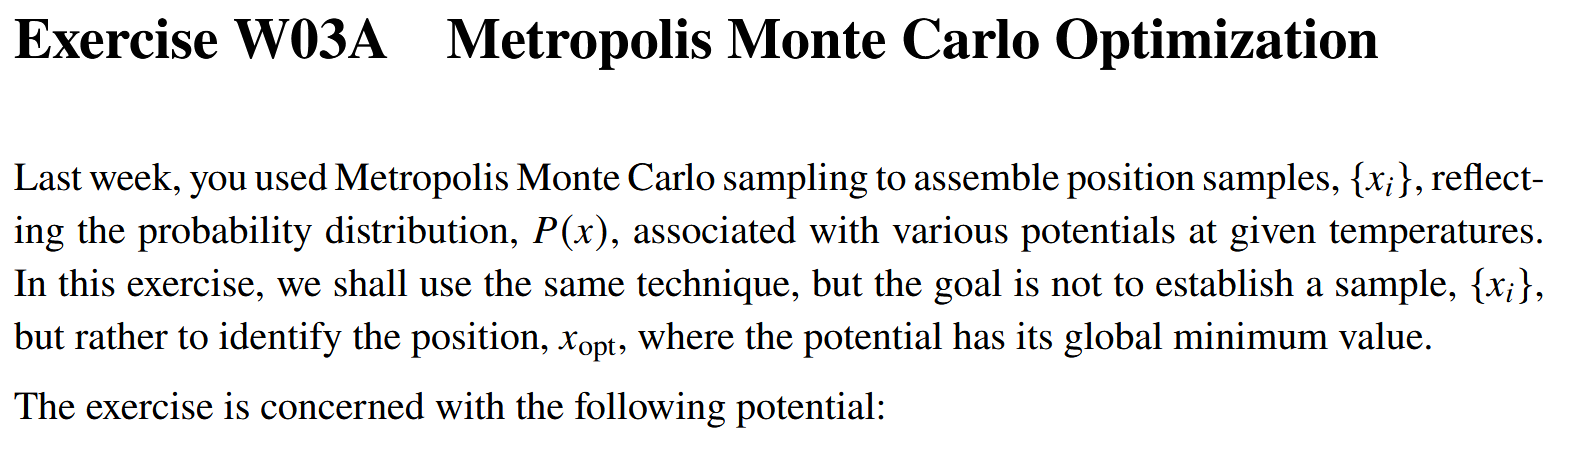

Text(0.5, 1.0, 'V(x)')

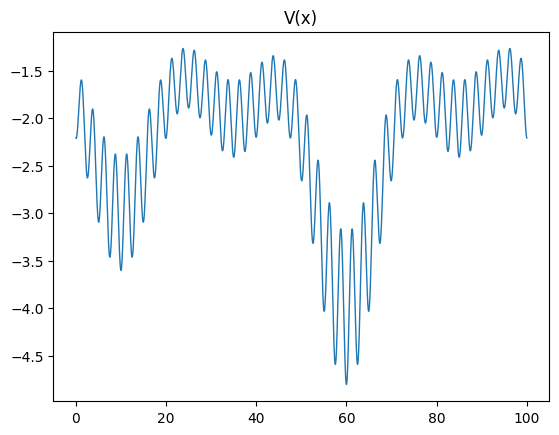

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def V(x):
    return (-1 -np.exp (-((x+15) /10) **2) 
    -2*np.exp (-((x -10) /10) **2) 
    -np.exp (-((x -35) /10) **2) 
    -3*np.exp (-((x -60) /10) **2) 
    -np.exp (-((x -85) /10) **2)
    -2*np.exp (-((x -110) /10) **2)) \
    * (1+1/5* np.cos (2* np.pi /2.5*x))

x = np.linspace(0, 100, 10000)
plt.plot(x, V(x), lw=1)
plt.title("V(x)")

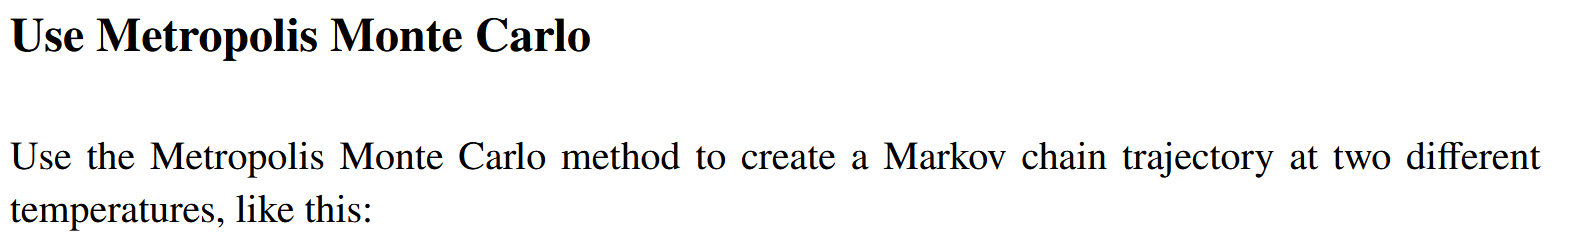

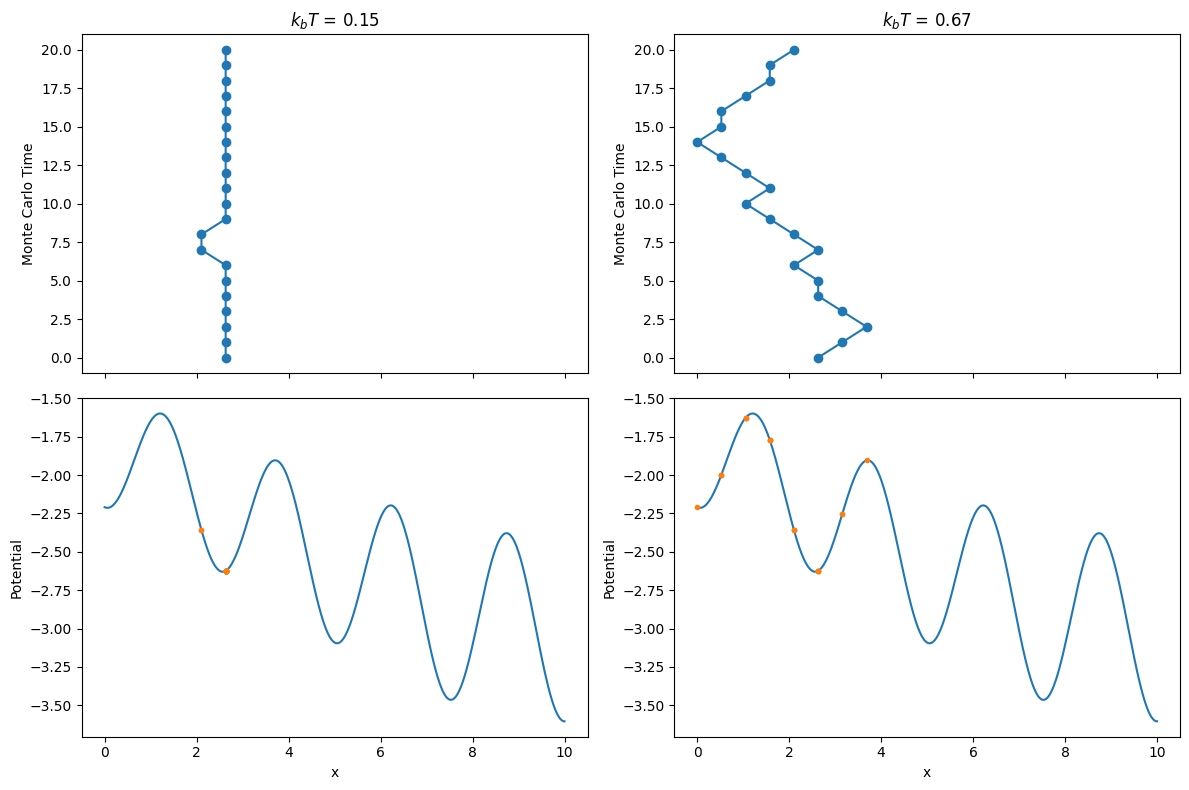

In [41]:
class DiscretizedMMC:
    def __init__(self, kbT= 0.15, xmin=-1, xmax=3, start_idx=0, N_points=41):
        self.kbT = kbT

        self.xmin = xmin
        self.xmax = xmax
        self.grid = np.linspace(self.xmin, self.xmax, N_points)
        self.dx = self.grid[1] - self.grid[0] 
        
        self.state =self.grid[start_idx]

    def V(self, x):
        return (-1 -np.exp (-((x+15) /10) **2) 
        -2*np.exp (-((x -10) /10) **2) 
        -np.exp (-((x -35) /10) **2) 
        -3*np.exp (-((x -60) /10) **2) 
        -np.exp (-((x -85) /10) **2)
        -2*np.exp (-((x -110) /10) **2)) \
        * (1+1/5* np.cos (2* np.pi /2.5*x))

    def propose(self):
        # Find the index of the current state on the grid
        idx = np.argmin(np.abs(self.grid - self.state))
        
        # Propose stepping left (-1) or right (+1) with equal probability
        step = np.random.choice([-1, 1])
        new_idx = idx + step
        
        # Apply boundary conditions: 
        if new_idx < 0:
            new_idx = 0
        elif new_idx >= len(self.grid):
            new_idx = len(self.grid) - 1
            
        return self.grid[new_idx]

    def step(self):
        x_m = self.propose()
        A = min(1.0, np.exp(-1/self.kbT * (self.V(x_m) - self.V(self.state))))
        if np.random.rand() < A:
            self.state = x_m

    def run_simulation(self, n=100_000):
        self.n = n
        history = [self.state]
        for _ in range(n):
            self.step()
            history.append(self.state)

        self.history = np.array(history)
        return self.history

    def plot(self, ax1, ax2):
        if not hasattr(self, 'history'):
            raise Exception('Simulation noot run')

        ax1.plot(self.history, range(len(self.history)), 'o-')
        ax1.set_ylabel('Monte Carlo Time')
        ax1.set_title(r'$k_bT$ = ' + f'{self.kbT}')

        x = np.linspace(self.xmin, self.xmax, 1000)
        ax2.plot(x, V(x))
        ax2.plot(self.history, V(self.history), '.')
        ax2.set_ylabel('Potential')
        ax2.set_xlabel('x')

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for i,k in enumerate([0.15, 0.67]):
    sim = DiscretizedMMC(kbT=k, xmin=0, xmax=10, N_points=20, start_idx=5)
    sim.run_simulation(20)
    sim.plot(axs[0, i], axs[1, i])

plt.tight_layout()
plt.show()



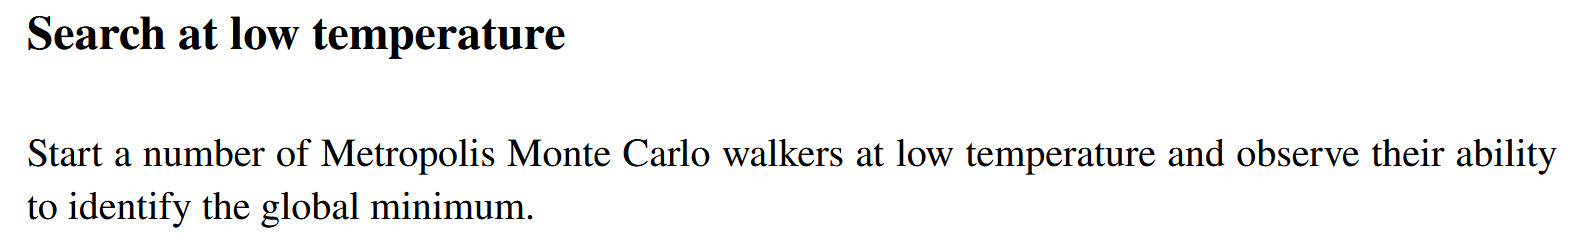

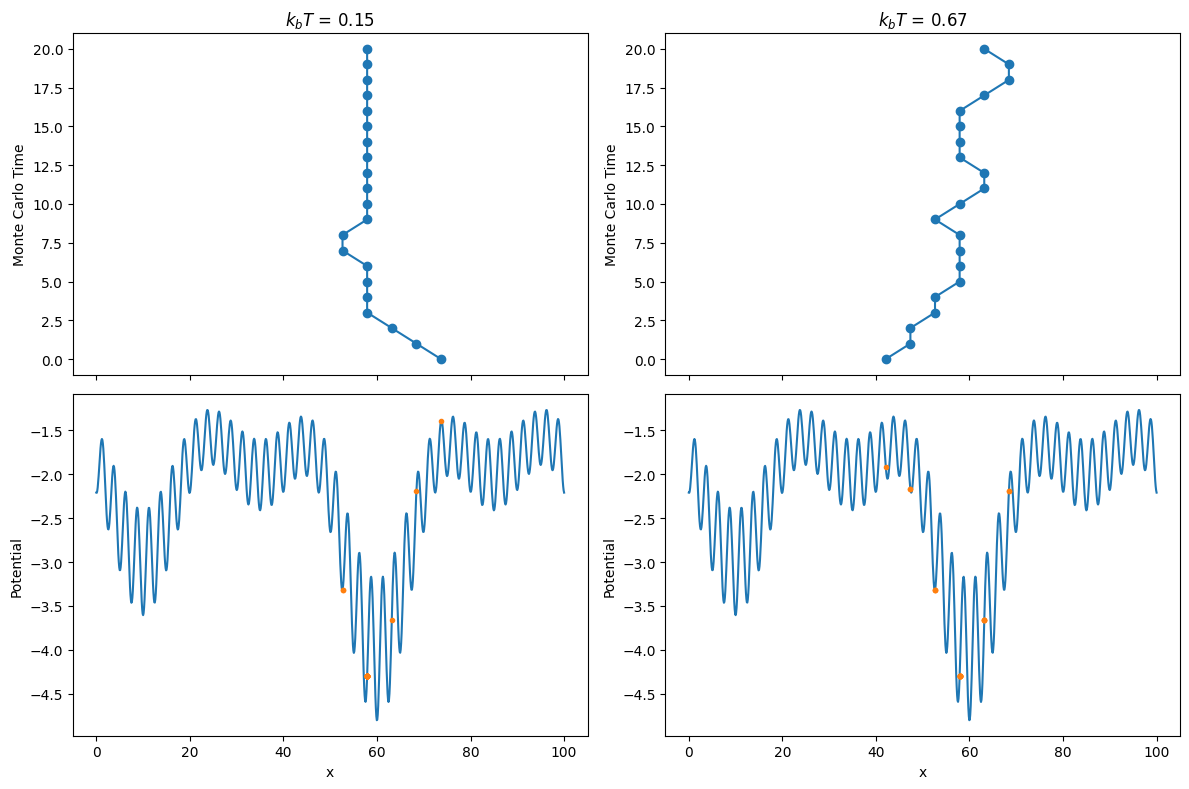

In [51]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)


for i,k in enumerate([0.15, 0.67]):
    sim = DiscretizedMMC(kbT=k, xmin=0, xmax=100, N_points=20, start_idx=np.random.randint(0, 20))
    sim.run_simulation(20)
    sim.plot(axs[0, i], axs[1, i])

plt.tight_layout()
plt.show()

From running the simulation multiple time, we can observe that it requires luck to find anywhere near the minimum well, but the hight temperature has a higher chance to go further away from its starting point. 